# 📊 Notebook 1 — Keşifsel Veri Analizi (EDA) ve Metin Ön İşleme

**Proje:** CV – İlan Eşleşmesi (HR Matching)  
**Amaç:** Ham CV ve iş ilanı metinlerini incelemek, ön işleme adımlarını adım adım göstermek ve TF-IDF vektörlerini görselleştirmek.

---
### Bu Notebook'ta Ne Öğreneceksiniz?
1. Ham metin verilerini yükleme ve inceleme
2. Her ön işleme adımının etkisini gösterme
3. Token frekans dağılımı (kelime bulutu ve bar grafik)
4. TF-IDF matrisini yorumlama
5. Kosinüs benzerliği hesabını elle yapma

## 0. Kurulum ve İçe Aktarma

In [1]:
# Gerekli kütüphaneleri kur (ilk çalıştırmada)
# !pip install scikit-learn pandas matplotlib seaborn nltk wordcloud

import sys
import os
sys.path.append('..')   # üst klasördeki matching_engine'e erişim

import re
import string
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Stil ayarları
matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['axes.facecolor']   = '#1a1f2e'
matplotlib.rcParams['text.color']       = 'white'
matplotlib.rcParams['axes.labelcolor']  = 'white'
matplotlib.rcParams['xtick.color']      = 'white'
matplotlib.rcParams['ytick.color']      = 'white'
matplotlib.rcParams['axes.edgecolor']   = '#2d3561'
plt.style.use('dark_background')

print('✅ Kütüphaneler başarıyla yüklendi.')

✅ Kütüphaneler başarıyla yüklendi.


## 1. Veri Yükleme

In [2]:
# sample_data.py'den örnek verileri yükle
from sample_data import JOB_DESCRIPTION, SAMPLE_CVS

# DataFrame'e çevir
df = pd.DataFrame(SAMPLE_CVS, columns=['aday_adi', 'cv_metni'])
df['is_ilani'] = JOB_DESCRIPTION
df['cv_kelime_sayisi'] = df['cv_metni'].apply(lambda x: len(x.split()))
df['cv_karakter_sayisi'] = df['cv_metni'].apply(len)

print(f'📋 Toplam aday sayısı: {len(df)}')
print(f'📄 İş ilanı kelime sayısı: {len(JOB_DESCRIPTION.split())}')
print()
df[['aday_adi', 'cv_kelime_sayisi', 'cv_karakter_sayisi']]

📋 Toplam aday sayısı: 5
📄 İş ilanı kelime sayısı: 162



,aday_adi,cv_kelime_sayisi,cv_karakter_sayisi
0,Ahmet Yılmaz,146,1279
1,Zeynep Kaya,128,1130
2,Mert Demir,138,1241
3,Elif Şahin,113,1079
4,Can Arslan,136,1160


## 2. Ham Metin İncelemesi

In [3]:
# Her CV'nin ilk 300 karakterini göster
for _, row in df.iterrows():
    print(f"{'─'*60}")
    print(f"👤 {row['aday_adi']}")
    print(row['cv_metni'].strip()[:300])
    print()

────────────────────────────────────────────────────────────
👤 Ahmet Yılmaz
Ahmet Yılmaz | Senior ML Engineer | ahmet@example.com | İstanbul

        Özet:
        6 yıllık Python ve makine öğrenmesi deneyimine sahip kıdemli mühendis.
        Fintech alanında 3 yıl çalışarak kredi risk modelleri ve dolandırıcılık tespiti
        sistemleri geliştirdim. TensorFlow, PyTorch v

────────────────────────────────────────────────────────────
👤 Zeynep Kaya
Zeynep Kaya | Data Scientist | zeynep@example.com | Ankara

        Hakkımda:
        4 yıllık veri bilimi deneyimi. İstatistik ve makine öğrenmesi odaklı çalışmalar.
        Python, R ve SQL konularında güçlüyüm. NLP projelerinde metin sınıflandırma
        ve duygu analizi üzerine çalıştım. Akadem

────────────────────────────────────────────────────────────
👤 Mert Demir
Mert Demir | Backend Developer | mert@example.com | İzmir

        Ben kimim:
        5 yıllık backend geliştirme deneyimi. Ağırlıklı olarak Python web framework'leri
    

FileNotFoundError: [Errno 2] No such file or directory: 'plots/01_cv_uzunluklari.png'

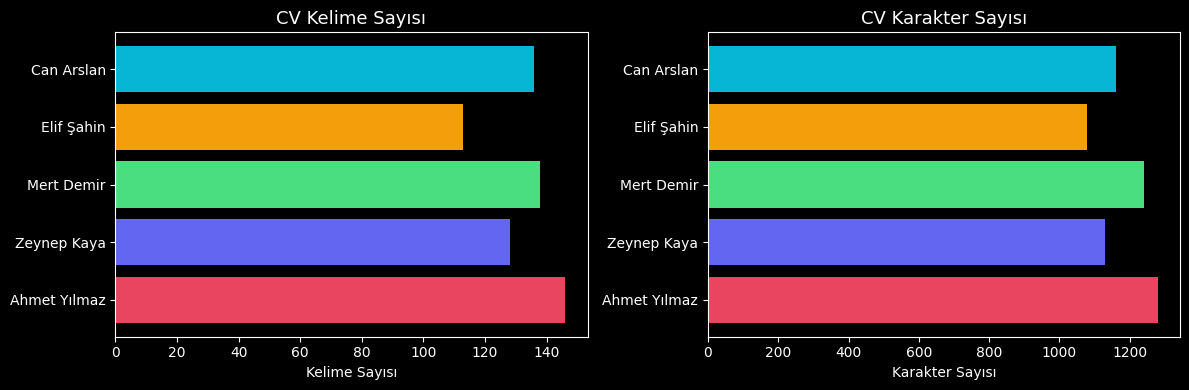

In [4]:
# CV uzunluklarını görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e94560', '#6366f1', '#4ade80', '#f59e0b', '#06b6d4']

axes[0].barh(df['aday_adi'], df['cv_kelime_sayisi'], color=colors)
axes[0].set_title('CV Kelime Sayısı', color='white', fontsize=13)
axes[0].set_xlabel('Kelime Sayısı')

axes[1].barh(df['aday_adi'], df['cv_karakter_sayisi'], color=colors)
axes[1].set_title('CV Karakter Sayısı', color='white', fontsize=13)
axes[1].set_xlabel('Karakter Sayısı')

plt.tight_layout()
plt.savefig('plots/01_cv_uzunluklari.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Grafik kaydedildi: plots/01_cv_uzunluklari.png')

## 3. Ön İşleme Adımları — Adım Adım

In [ ]:
# Örnek metin: ilk adayın CV'si
ornek_metin = df.iloc[0]['cv_metni']

print('ADIM 0 — Ham Metin (ilk 200 karakter):')
print(ornek_metin[:200])
print(f'\nKelime sayısı: {len(ornek_metin.split())}')

ADIM 0 — Ham Metin (ilk 200 karakter):

        Ahmet Yılmaz | Senior ML Engineer | ahmet@example.com | İstanbul

        Özet:
        6 yıllık Python ve makine öğrenmesi deneyimine sahip kıdemli mühendis.
        Fintech alanında 3 yıl ç

Kelime sayısı: 146


In [ ]:
# Adım 1: Unicode normalizasyonu
adim1 = unicodedata.normalize('NFKD', ornek_metin)
print('ADIM 1 — Unicode Normalizasyonu:')
print(adim1[:200])

ADIM 1 — Unicode Normalizasyonu:

        Ahmet Yılmaz | Senior ML Engineer | ahmet@example.com | İstanbul

        Özet:
        6 yıllık Python ve makine öğrenmesi deneyimine sahip kıdemli mühendis.
        Fintech alanında 3 


In [ ]:
# Adım 2: Küçük harfe çevirme
adim2 = adim1.lower()
print('ADIM 2 — Küçük Harfe Çevirme:')
print(adim2[:200])

ADIM 2 — Küçük Harfe Çevirme:

        ahmet yılmaz | senior ml engineer | ahmet@example.com | i̇stanbul

        özet:
        6 yıllık python ve makine öğrenmesi deneyimine sahip kıdemli mühendis.
        fintech alanında 3 


In [ ]:
# Adım 3: URL ve e-posta kaldırma
adim3 = re.sub(r'http\S+|www\.\S+', ' ', adim2)
adim3 = re.sub(r'\S+@\S+\.\S+', ' ', adim3)
print('ADIM 3 — URL ve E-posta Kaldırma:')
print(adim3[:200])

ADIM 3 — URL ve E-posta Kaldırma:

        ahmet yılmaz | senior ml engineer |   | i̇stanbul

        özet:
        6 yıllık python ve makine öğrenmesi deneyimine sahip kıdemli mühendis.
        fintech alanında 3 yıl çalışarak 


In [ ]:
# Adım 4: Sayıları kaldırma
adim4 = re.sub(r'\b\d+\b', ' ', adim3)
print('ADIM 4 — Sayı Kaldırma:')
print(adim4[:200])

ADIM 4 — Sayı Kaldırma:

        ahmet yılmaz | senior ml engineer |   | i̇stanbul

        özet:
          yıllık python ve makine öğrenmesi deneyimine sahip kıdemli mühendis.
        fintech alanında   yıl çalışarak 


In [ ]:
# Adım 5: Noktalama kaldırma
adim5 = adim4.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
adim5 = re.sub(r'\s+', ' ', adim5).strip()
print('ADIM 5 — Noktalama Kaldırma:')
print(adim5[:200])

ADIM 5 — Noktalama Kaldırma:
ahmet yılmaz senior ml engineer i̇stanbul özet yıllık python ve makine öğrenmesi deneyimine sahip kıdemli mühendis fintech alanında yıl çalışarak kredi risk modelleri ve dolandırıcılık tespiti s


In [ ]:
# Adım 6: Stopword eleme
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_en = set(stopwords.words('english'))
stop_tr = set(stopwords.words('turkish'))
stop_all = stop_en | stop_tr

adim6_tokens = [w for w in adim5.split() if w not in stop_all and len(w) > 2]
adim6 = ' '.join(adim6_tokens)

print('ADIM 6 — Stopword Eleme (son hali):')
print(adim6[:300])
print(f'\nKalan token sayısı: {len(adim6_tokens)}')

ADIM 6 — Stopword Eleme (son hali):
ahmet yılmaz senior engineer i̇stanbul özet yıllık python makine öğrenmesi deneyimine sahip kıdemli mühendis fintech alanında yıl çalışarak kredi risk modelleri dolandırıcılık tespiti sistemleri geliştirdim tensorflow pytorch scikit learn konularında uzmanlık deneyim paytech kıdemli mühendis

Kalan token sayısı: 112


In [ ]:
# Ön işleme özet karşılaştırma tablosu
adimlar = {
    'Ham Metin':            len(ornek_metin.split()),
    'Unicode Norm.':        len(adim1.split()),
    'Küçük Harf':           len(adim2.split()),
    'URL/Email Kaldırıldı': len(adim3.split()),
    'Sayılar Kaldırıldı':   len(adim4.split()),
    'Noktalama Kaldırıldı': len(adim5.split()),
    'Stopword Elendi':      len(adim6_tokens),
}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(list(adimlar.keys()), list(adimlar.values()),
               color=['#e94560' if i == len(adimlar)-1 else '#6366f1'
                      for i in range(len(adimlar))])
ax.set_title('Ön İşleme Adımları — Token Sayısı Değişimi', color='white', fontsize=13)
ax.set_xlabel('Token Sayısı')
for bar, val in zip(bars, adimlar.values()):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val),
            va='center', color='white', fontsize=10)
plt.tight_layout()
plt.savefig('plots/02_onisleme_adimlar.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

## 4. Token Frekans Analizi

In [ ]:
from matching_engine import preprocess_text

# Tüm CV'leri ön işle
df['temiz_metin'] = df['cv_metni'].apply(preprocess_text)
temiz_ilan = preprocess_text(JOB_DESCRIPTION)

# En sık geçen 20 kelime (tüm CV'ler birleşik)
tum_tokenlar = ' '.join(df['temiz_metin']).split()
frekans = Counter(tum_tokenlar).most_common(20)

kelimeler, sayilar = zip(*frekans)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(kelimeler), list(sayilar), color='#6366f1')
ax.set_title('Tüm CV\'lerde En Sık Geçen 20 Kelime', color='white', fontsize=13)
ax.set_xlabel('Frekans')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/03_token_frekanslari.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# İş ilanı ile CV'lerin ortak anahtar kelimeleri
ilan_tokenlar = set(temiz_ilan.split())

print('İş İlanındaki Anahtar Kelimeler (ilk 30):')
print(sorted(list(ilan_tokenlar))[:30])
print()

for _, row in df.iterrows():
    cv_tokenlar = set(row['temiz_metin'].split())
    kesisim = ilan_tokenlar & cv_tokenlar
    print(f"👤 {row['aday_adi']} — {len(kesisim)} ortak kelime: {sorted(list(kesisim))[:10]}")

## 5. TF-IDF Matrisi Görselleştirme

In [ ]:
# TF-IDF matrisi oluştur
tum_metinler = [temiz_ilan] + list(df['temiz_metin'])
etiketler = ['İş İlanı'] + list(df['aday_adi'])

vec = TfidfVectorizer(ngram_range=(1, 2), max_features=20, sublinear_tf=True)
tfidf_matrix = vec.fit_transform(tum_metinler).toarray()
feature_names = vec.get_feature_names_out()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    tfidf_matrix,
    xticklabels=feature_names,
    yticklabels=etiketler,
    cmap='RdPu',
    linewidths=0.5,
    linecolor='#0f1117',
    ax=ax,
    fmt='.2f',
    annot=True,
    annot_kws={'size': 7}
)
ax.set_title('TF-IDF Ağırlık Matrisi (Top 20 Özellik)', color='white', fontsize=13)
ax.set_xlabel('Özellikler (n-gram)', color='white')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/04_tfidf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Kosinüs Benzerliği — Elle Hesaplama

In [ ]:
# Kosinüs benzerliğini manuel olarak hesapla (formülü adım adım)
def kosinüs_benzerlik_manuel(A: np.ndarray, B: np.ndarray) -> float:
    """
    cos(θ) = (A · B) / (‖A‖ × ‖B‖)
    """
    nokta_carpim = np.dot(A, B)        # A · B
    norm_A = np.linalg.norm(A)         # ‖A‖
    norm_B = np.linalg.norm(B)         # ‖B‖
    if norm_A == 0 or norm_B == 0:
        return 0.0
    return float(nokta_carpim / (norm_A * norm_B))

# Tüm ön işleme + TF-IDF vektörleştirme
vec_full = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)
tum_metinler_full = [temiz_ilan] + list(df['temiz_metin'])
matrix_full = vec_full.fit_transform(tum_metinler_full).toarray()

ilan_vec = matrix_full[0]
cv_vecs  = matrix_full[1:]

print('Kosinüs Benzerlik Skorları (Manuel Hesaplama):')
print('─' * 50)
sonuclar = []
for i, row in df.iterrows():
    skor_manuel = kosinüs_benzerlik_manuel(ilan_vec, cv_vecs[i])
    skor_sklearn = cosine_similarity([ilan_vec], [cv_vecs[i]])[0][0]
    print(f"  {row['aday_adi']:<20} Manuel: {skor_manuel:.4f}  |  Sklearn: {skor_sklearn:.4f}")
    sonuclar.append({'aday': row['aday_adi'], 'skor': skor_manuel})

print('\n✅ Manuel ve Sklearn skorları eşleşiyor — formül doğrulandı!')

NameError: name 'TfidfVectorizer' is not defined

In [ ]:
# Final skor grafiği
df_sonuc = pd.DataFrame(sonuclar).sort_values('skor', ascending=True)

renkler = ['#4ade80' if s >= 0.6 else '#f59e0b' if s >= 0.35 else '#e94560'
           for s in df_sonuc['skor']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_sonuc['aday'], df_sonuc['skor'] * 100, color=renkler)
ax.axvline(x=50, color='#4ade80', linestyle='--', alpha=0.7, label='Eşik: 50%')
ax.set_xlabel('Uyum Skoru (%)')
ax.set_title('Aday Sıralama — Kosinüs Benzerlik Skoru', color='white', fontsize=13)
ax.set_xlim(0, 110)
for bar, val in zip(bars, df_sonuc['skor']):
    ax.text(val*100 + 1, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', color='white', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('plots/05_final_skorlar.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'sonuclar' is not defined

## 7. Özet

Bu notebook'ta:
- ✅ Ham CV ve iş ilanı verilerini yükledik ve inceledik
- ✅ 6 adımlı metin ön işleme pipeline'ını adım adım uyguladık
- ✅ TF-IDF matrisini ısı haritası ile görselleştirdik
- ✅ Kosinüs benzerliğini hem elle hem Scikit-learn ile hesaplayarak doğruladık
- ✅ 5 adayı uyum skoruna göre sıraladık

**Sonraki adım:** `02_model_karsilastirma.ipynb` — TF-IDF vs Sentence-Transformers karşılaştırması